# PCA для `load_wine`

## План

1. Імпортувати потрібні бібліотеки.
2. Завантажити `load_wine`.
3. Створити `DataFrame` з ознаками і `Series` з target.
4. Перевірити масштаби ознак.
5. Масштабувати дані через `StandardScaler`.
6. Навчити PCA з 2 компонентами і отримати 2D-проекцію.
7. Побудувати готові графіки.
8. Отримати `explained_variance_ratio_` і cumulative explained variance.

## 1. Імпорти

Цю клітинку міняти не потрібно.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

plt.style.use("seaborn-v0_8-whitegrid")
OUTPUT_DIR = Path.cwd()

## 2. Завантаження даних

Заповніть пропуски так, щоб:

- `wine` містив результат `load_wine()`;
- `X` був `pandas.DataFrame` з ознаками;
- `y` був `pandas.Series` з цільовою змінною.

In [2]:
# TODO: завантажте датасет load_wine в змінну wine
wine = load_wine()

# TODO: створіть X DataFrame з wine.data і назвами колонок wine.feature_names
X = pd.DataFrame(wine.data, columns=wine.feature_names)

# TODO: створіть y Series з wine.target і назвою "target"
y = pd.Series(wine.target, name="target")

display(X.head())
print(f"Розмір матриці ознак: {X.shape[0]} рядків x {X.shape[1]} ознак")
print(f"Класи: {list(wine.target_names)}")

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


Розмір матриці ознак: 178 рядків x 13 ознак
Класи: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]


## 3. Перевірка масштабу ознак

Заповніть пропуски, щоб подивитися середнє і стандартне відхилення кожної ознаки до масштабування.

In [3]:
scale_summary = pd.DataFrame({
    "mean_before": X.mean(),
    "std_before": X.std()
}).round(2)

scale_summary.head(8)

,mean_before,std_before
alcohol,13.00,0.81
malic_acid,2.34,1.12
ash,2.37,0.27
alcalinity_of_ash,19.49,3.34
magnesium,99.74,14.28
total_phenols,2.30,0.63
flavanoids,2.03,1.00
nonflavanoid_phenols,0.36,0.12


## 4. Масштабування даних

PCA потрібно застосовувати до масштабованих ознак. Заповніть пропуски так, щоб:

- `scaler` був об'єктом `StandardScaler`;
- `X_scaled` містив результат `fit_transform` для `X`;
- `scaled_summary` показував mean/std після масштабування.

In [4]:
# створіть StandardScaler
scaler = StandardScaler()

# навчіть scaler на X і одразу перетворіть X
X_scaled = scaler.fit_transform(X)

scaled_summary = pd.DataFrame(X_scaled, columns=X.columns).agg(["mean", "std"]).T
scaled_summary.head(8).round(2)

,mean,std
alcohol,-0.0,1.0
malic_acid,-0.0,1.0
ash,-0.0,1.0
alcalinity_of_ash,-0.0,1.0
magnesium,-0.0,1.0
total_phenols,0.0,1.0
flavanoids,-0.0,1.0
nonflavanoid_phenols,0.0,1.0


Після правильного масштабування середнє кожної ознаки має бути близьке до `0`, а стандартне відхилення близьке до `1`.

## 5. PCA-проекція

Заповніть пропуски так, щоб:

- `pca_2d` був PCA з двома компонентами;
- `X_pca` містив 2D-проекцію масштабованих даних;
- `pca_df` містив колонки `PC1`, `PC2` і `target`.

In [5]:
# TODO: створіть PCA з двома компонентами
pca_2d = PCA(n_components=2)

# TODO: навчіть PCA на X_scaled і отримайте перетворені дані
X_pca = pca_2d.fit_transform(X_scaled)

# TODO: створіть pca_df DataFrame з X_pca і назвами колонок PC1, PC2
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])

# TODO: додайте target до pca_df
pca_df["target"] = y

## 6. PCA-графік

Код нижче міняти не потрібно. Якщо попередні клітинки заповнені правильно, він побудує 2D PCA-проекцію.

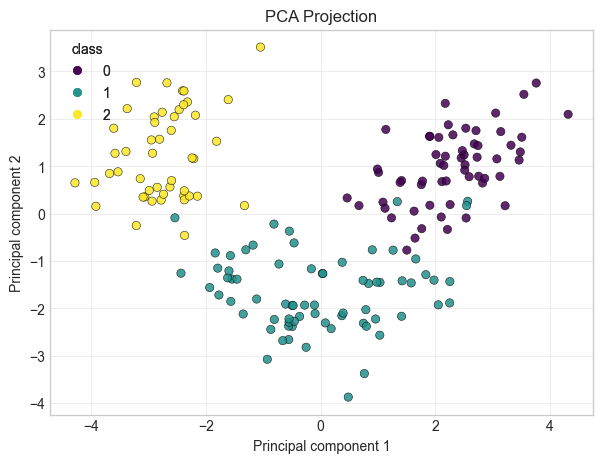

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["target"],
    cmap="viridis",
    edgecolor="black",
    linewidth=0.4,
    alpha=0.85,
)
ax.set_title("PCA Projection")
ax.set_xlabel("Principal component 1")
ax.set_ylabel("Principal component 2")
legend = ax.legend(*scatter.legend_elements(), title="class")
ax.add_artist(legend)
plt.show()

## 7. Збереження PCA-графіка

Цю клітинку міняти не потрібно. Вона зберігає готову PCA-візуалізацію у файл.

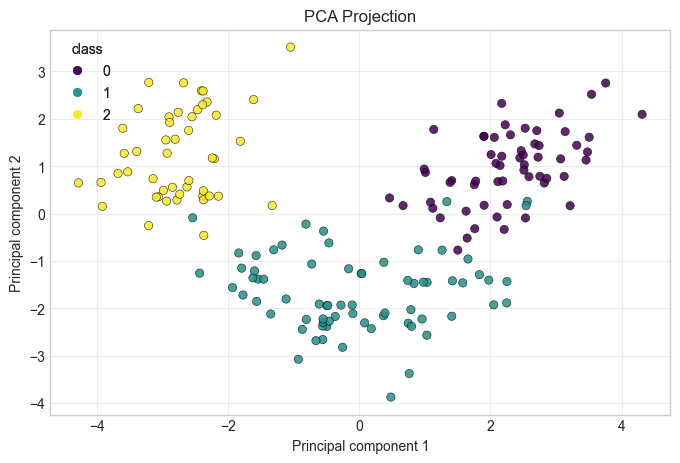

Зображення збережено: C:\Users\Lenovo\Downloads\PythonAI\заняття_16\pca_projection_student.png


In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["target"],
    cmap="viridis",
    edgecolor="black",
    linewidth=0.4,
    alpha=0.85,
)
ax.set_title("PCA Projection")
ax.set_xlabel("Principal component 1")
ax.set_ylabel("Principal component 2")
legend = ax.legend(*scatter.legend_elements(), title="class")
ax.add_artist(legend)

output_path = OUTPUT_DIR / "pca_projection_student.png"
fig.savefig(output_path, dpi=160, bbox_inches="tight")
plt.show()

print(f"Зображення збережено: {output_path}")

## 8. Explained variance

Заповніть пропуски, щоб отримати частку варіативності, яку пояснюють перші дві PCA-компоненти.

In [8]:
explained = pd.Series(
    pca_2d.explained_variance_ratio_,
    index=["PC1", "PC2"],
    name="explained_variance_ratio",
)

display(explained.to_frame().round(3))
print(f"Разом перші 2 компоненти пояснюють: {explained.sum():.1%} варіативності")

,explained_variance_ratio
PC1,0.362
PC2,0.192


Разом перші 2 компоненти пояснюють: 55.4% варіативності


## 9. Cumulative explained variance

Заповніть пропуски так, щоб навчити PCA з усіма компонентами і знайти, скільки компонентів потрібно для пояснення хоча б 90% варіативності.

In [10]:
# TODO: створіть PCA без обмеження кількості компонентів. Назвіть змінну pca_full
pca_full = PCA()

# TODO: навчіть PCA на масштабованих даних
pca_full.fit(X_scaled)

variance_df = pd.DataFrame({
    "component": range(1, len(pca_full.explained_variance_ratio_) + 1),
    "explained": pca_full.explained_variance_ratio_
})

# TODO: створіть колонку cumulative як накопичену суму explained
variance_df["cumulative"] = variance_df["explained"].cumsum()

components_for_90 = variance_df.loc[variance_df["cumulative"] >= 0.90, "component"].iloc[0]

display(variance_df.head(10).round(3))
print(f"Для пояснення >= 90% варіативності потрібно компонентів: {components_for_90}")

,component,explained,cumulative
0,1,0.362,0.362
1,2,0.192,0.554
2,3,0.111,0.665
3,4,0.071,0.736
4,5,0.066,0.802
5,6,0.049,0.851
6,7,0.042,0.893
7,8,0.027,0.920
8,9,0.022,0.942
9,10,0.019,0.962


Для пояснення >= 90% варіативності потрібно компонентів: 8


## 10. Графік cumulative explained variance

Код нижче міняти не потрібно. Він візуалізує результат із попередньої клітинки.

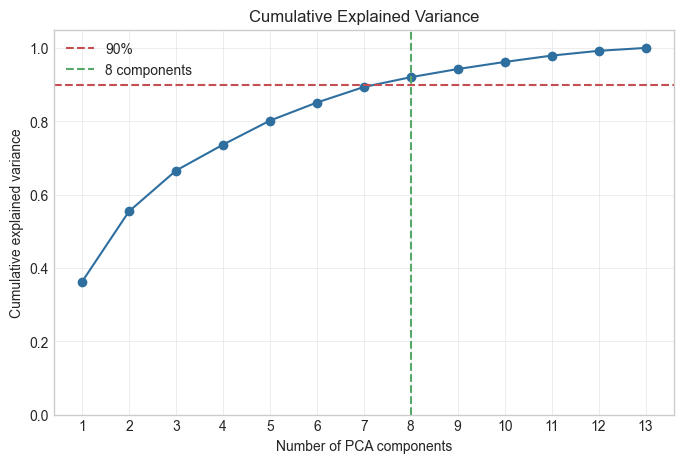

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    variance_df["component"],
    variance_df["cumulative"],
    marker="o",
    color="#2f6f9f",
)
ax.axhline(0.90, color="#c44e52", linestyle="--", label="90%")
ax.axvline(components_for_90, color="#55a868", linestyle="--", label=f"{components_for_90} components")
ax.set_title("Cumulative Explained Variance")
ax.set_xlabel("Number of PCA components")
ax.set_ylabel("Cumulative explained variance")
ax.set_xticks(variance_df["component"])
ax.set_ylim(0, 1.05)
ax.legend()
plt.show()

## Короткий висновок

Після заповнення notebook дайте відповіді в markdown-комірці нижче:

1. Чому перед PCA потрібно масштабувати ознаки?
Тому що ознаки мають різні масштаби. Масштабування робить їх однаково важливими для PCA.

2. Скільки варіативності пояснюють перші 2 компоненти?
Перші 2 компоненти пояснюють 55.4% варіативності даних.

3. Скільки компонентів потрібно для приблизно 90% варіативності?
Для пояснення приблизно 90% варіативності потрібно 8 компонентів.

4. Чому 2D PCA-графік не показує всю інформацію з початкових 13 ознак?
Тому що графік відображає лише дві головні компоненти, а решта інформації залишається в інших компонентах.

## Ваш висновок

Напишіть тут 3-5 речень після запуску всіх клітинок.